# Complex Networks: Section VI Spectral MFPT vs r

This notebook plots $\langle T \rangle$ against reset rate $r$ for the complex-network Section VI spectral implementation (`complex_mfpt`) at fixed network mean degree and multiple initial magnetizations $m_0$. It also compares the `m0 = 0.90` theoretical curve against discrete-time simulations from `first_passage_time_discrete_complex` on the same graph realization.

In [7]:
using Printf
using Plots
using Graphs
using Random
using Statistics

candidates = [abspath(pwd()), abspath(joinpath(pwd(), "..")), abspath(joinpath(pwd(), "..", ".."))]
project_root = nothing
for p in candidates
    if isfile(joinpath(p, "src", "VoterResetting.jl"))
        global project_root = p
        break
    end
end
project_root === nothing && error("Could not locate project root containing src/VoterResetting.jl from pwd=$(pwd())")

include(joinpath(project_root, "src", "VoterResetting.jl"))
const VR = VoterResetting
gr()
println("Loaded VoterResetting from: $(project_root)")

Loaded VoterResetting from: c:\Users\gerar\Desktop\Escola\Universitat\Master\TFM\voter-model-stochastic-resetting\


In [8]:
Random.seed!(1234)

N = 200
mu = 12.0
p_edge = min(1.0, mu / (N - 1))
g = erdos_renyi(N, p_edge)

if !is_connected(g)
    comps = connected_components(g)
    giant = comps[argmax(length.(comps))]
    g = induced_subgraph(g, giant)[1]
    println("Graph not connected: using giant component with N=$(nv(g)).")
end

m0_values = [0.00, 0.25, 0.50, 0.75, 0.90]
r_values = collect(range(0.0, 0.99, length = 120))
max_states = 200_000

# Target m0 for single-curve theory diagnostics.
m0_target = 0.90
# Mean-degree sweep for theory-only comparison at fixed m0_target.
mu_values = [6.0, 10.0, 14.0, 18.0]

println(@sprintf("Graph summary: N=%d, E=%d, mean degree=%.3f", nv(g), ne(g), 2 * ne(g) / nv(g)))

Graph summary: N=200, E=1260, mean degree=12.600


In [9]:
gap_info = VR.complex_spectral_gap(g; max_states = max_states)
println(@sprintf("Section VI spectral gap = %.6e", gap_info.spectral_gap))
println(@sprintf("Asymptotic scale mu2/(N^2*mu1^2) = %.6e", gap_info.asymptotic_gap_scale))
println(@sprintf("Gap / scale = %.6f", gap_info.ratio_gap_to_asymptotic))

Section VI spectral gap = 1.280018e-05
Asymptotic scale mu2/(N^2*mu1^2) = 2.723765e-05
Gap / scale = 0.469944


In [10]:
mfpt_by_m0 = Dict{Float64, Vector{Float64}}()

for m0 in m0_values
    tt = Vector{Float64}(undef, length(r_values))
    for (i, r) in enumerate(r_values)
        tt[i] = VR.complex_mfpt(
            g,
            m0;
            r = r,
            max_states = max_states,
        )
    end
    mfpt_by_m0[m0] = tt
end

println(@sprintf("Computed %d complex spectral MFPT(r) curves.", length(m0_values)))

Computed 5 complex spectral MFPT(r) curves.


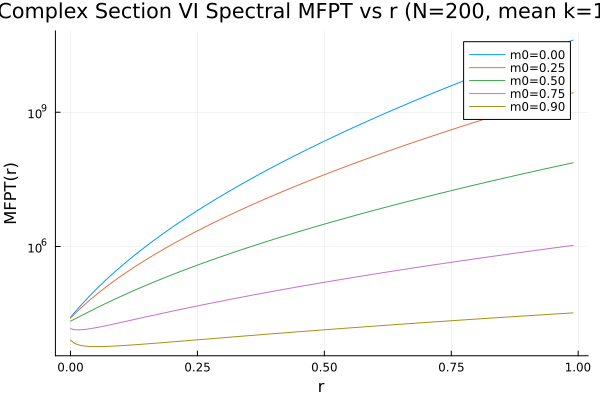

In [11]:
p_full = plot(
    xlabel = "r",
    ylabel = "MFPT(r)",
    title = "Complex Section VI Spectral MFPT vs r (N=$(nv(g)), mean k=$(round(2*ne(g)/nv(g), digits=2)))",
    legend = :topright,
    linewidth = 2.5,
    yscale = :log10,
)

for m0 in m0_values
    tt = mfpt_by_m0[m0]
    mask = isfinite.(tt) .& (tt .> 0.0)
    plot!(p_full, r_values[mask], tt[mask], label = @sprintf("m0=%.2f", m0))
end

p_full

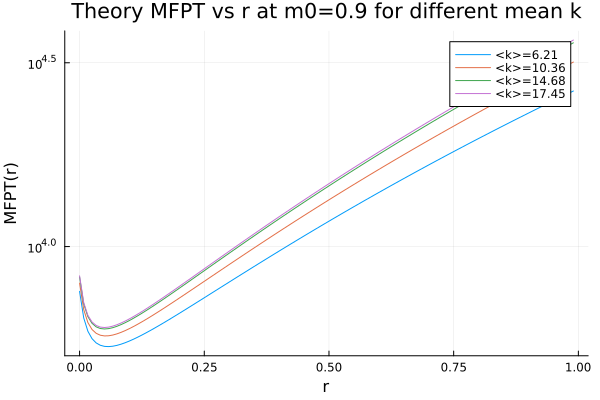

In [12]:
p_target = plot(
    xlabel = "r",
    ylabel = "MFPT(r)",
    title = "Theory MFPT vs r at m0=$(round(m0_target, digits=2)) for different mean k",
    legend = :topright,
    linewidth = 2.8,
    yscale = :log10,
)

for (j, mu_k) in enumerate(mu_values)
    # Keep topology family identical (Erdos-Renyi) and vary only mean degree.
    Random.seed!(1234 + j)
    p_edge_k = min(1.0, mu_k / (N - 1))
    g_k = erdos_renyi(N, p_edge_k)

    if !is_connected(g_k)
        comps_k = connected_components(g_k)
        giant_k = comps_k[argmax(length.(comps_k))]
        g_k = induced_subgraph(g_k, giant_k)[1]
    end

    theory_k = Vector{Float64}(undef, length(r_values))
    for (i, r) in enumerate(r_values)
        theory_k[i] = VR.complex_mfpt(
            g_k,
            m0_target;
            r = r,
            max_states = max_states,
        )
    end

    mask_k = isfinite.(theory_k) .& (theory_k .> 0.0)
    mean_k_eff = round(2 * ne(g_k) / nv(g_k), digits=2)
    plot!(p_target, r_values[mask_k], theory_k[mask_k], label = @sprintf("<k>=%.2f", mean_k_eff))
end

p_target